### 1. Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = '/content/Tragico_student-dropout-dataset_v3.csv'
df = pd.read_csv(file_path)

# 1. Data Quality and Cleaning Checks
print("--- Data Quality Checks ---")
print(f"Dataset Shape: {df.shape}")
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary (Outlier Detection):")
display(df.describe())


--- Data Quality Checks ---
Dataset Shape: (10000, 19)

Missing Values:
Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64

Duplicate Rows:
0

Statistical Summary (Outlier Detection):


,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00000,10000.00000,9500.000000,9500.000000,10000.00000,10000.000000,10000.00000,9500.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,21.02606,38377.247474,4.014592,81.73683,1.799700,30.17926,5.507147,2.308440,2.300057,2.298761,0.23540
std,2886.89568,2.13981,20496.232179,1.295450,8.22093,1.344307,11.91887,1.765951,1.061717,1.074407,1.072555,0.42427
min,1.00000,17.00000,25000.000000,0.500000,38.20000,0.000000,5.00000,1.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,19.50000,25000.000000,3.160000,76.40000,1.000000,21.90000,4.300000,1.550000,1.520000,1.520000,0.00000
50%,5000.50000,21.00000,29740.500000,4.000000,81.80000,2.000000,30.20000,5.500000,2.350000,2.350000,2.350000,0.00000
75%,7500.25000,22.50000,44520.000000,4.870000,87.30000,3.000000,38.40000,6.700000,3.120000,3.150000,3.150000,0.00000
max,10000.00000,29.60000,316601.000000,8.980000,100.00000,8.000000,74.90000,10.000000,4.000000,4.000000,4.000000,1.00000


**Explanation**:

This first inital setup imports essential libraries then, it loads the student dropout dataset into a DataFrame. Finally, it prints the dataset's dimensions, checks for missing values and duplicate rows, and displays a statistical summary to help identify potential outliers or data entry errors.

### 2. Univariate Analysis

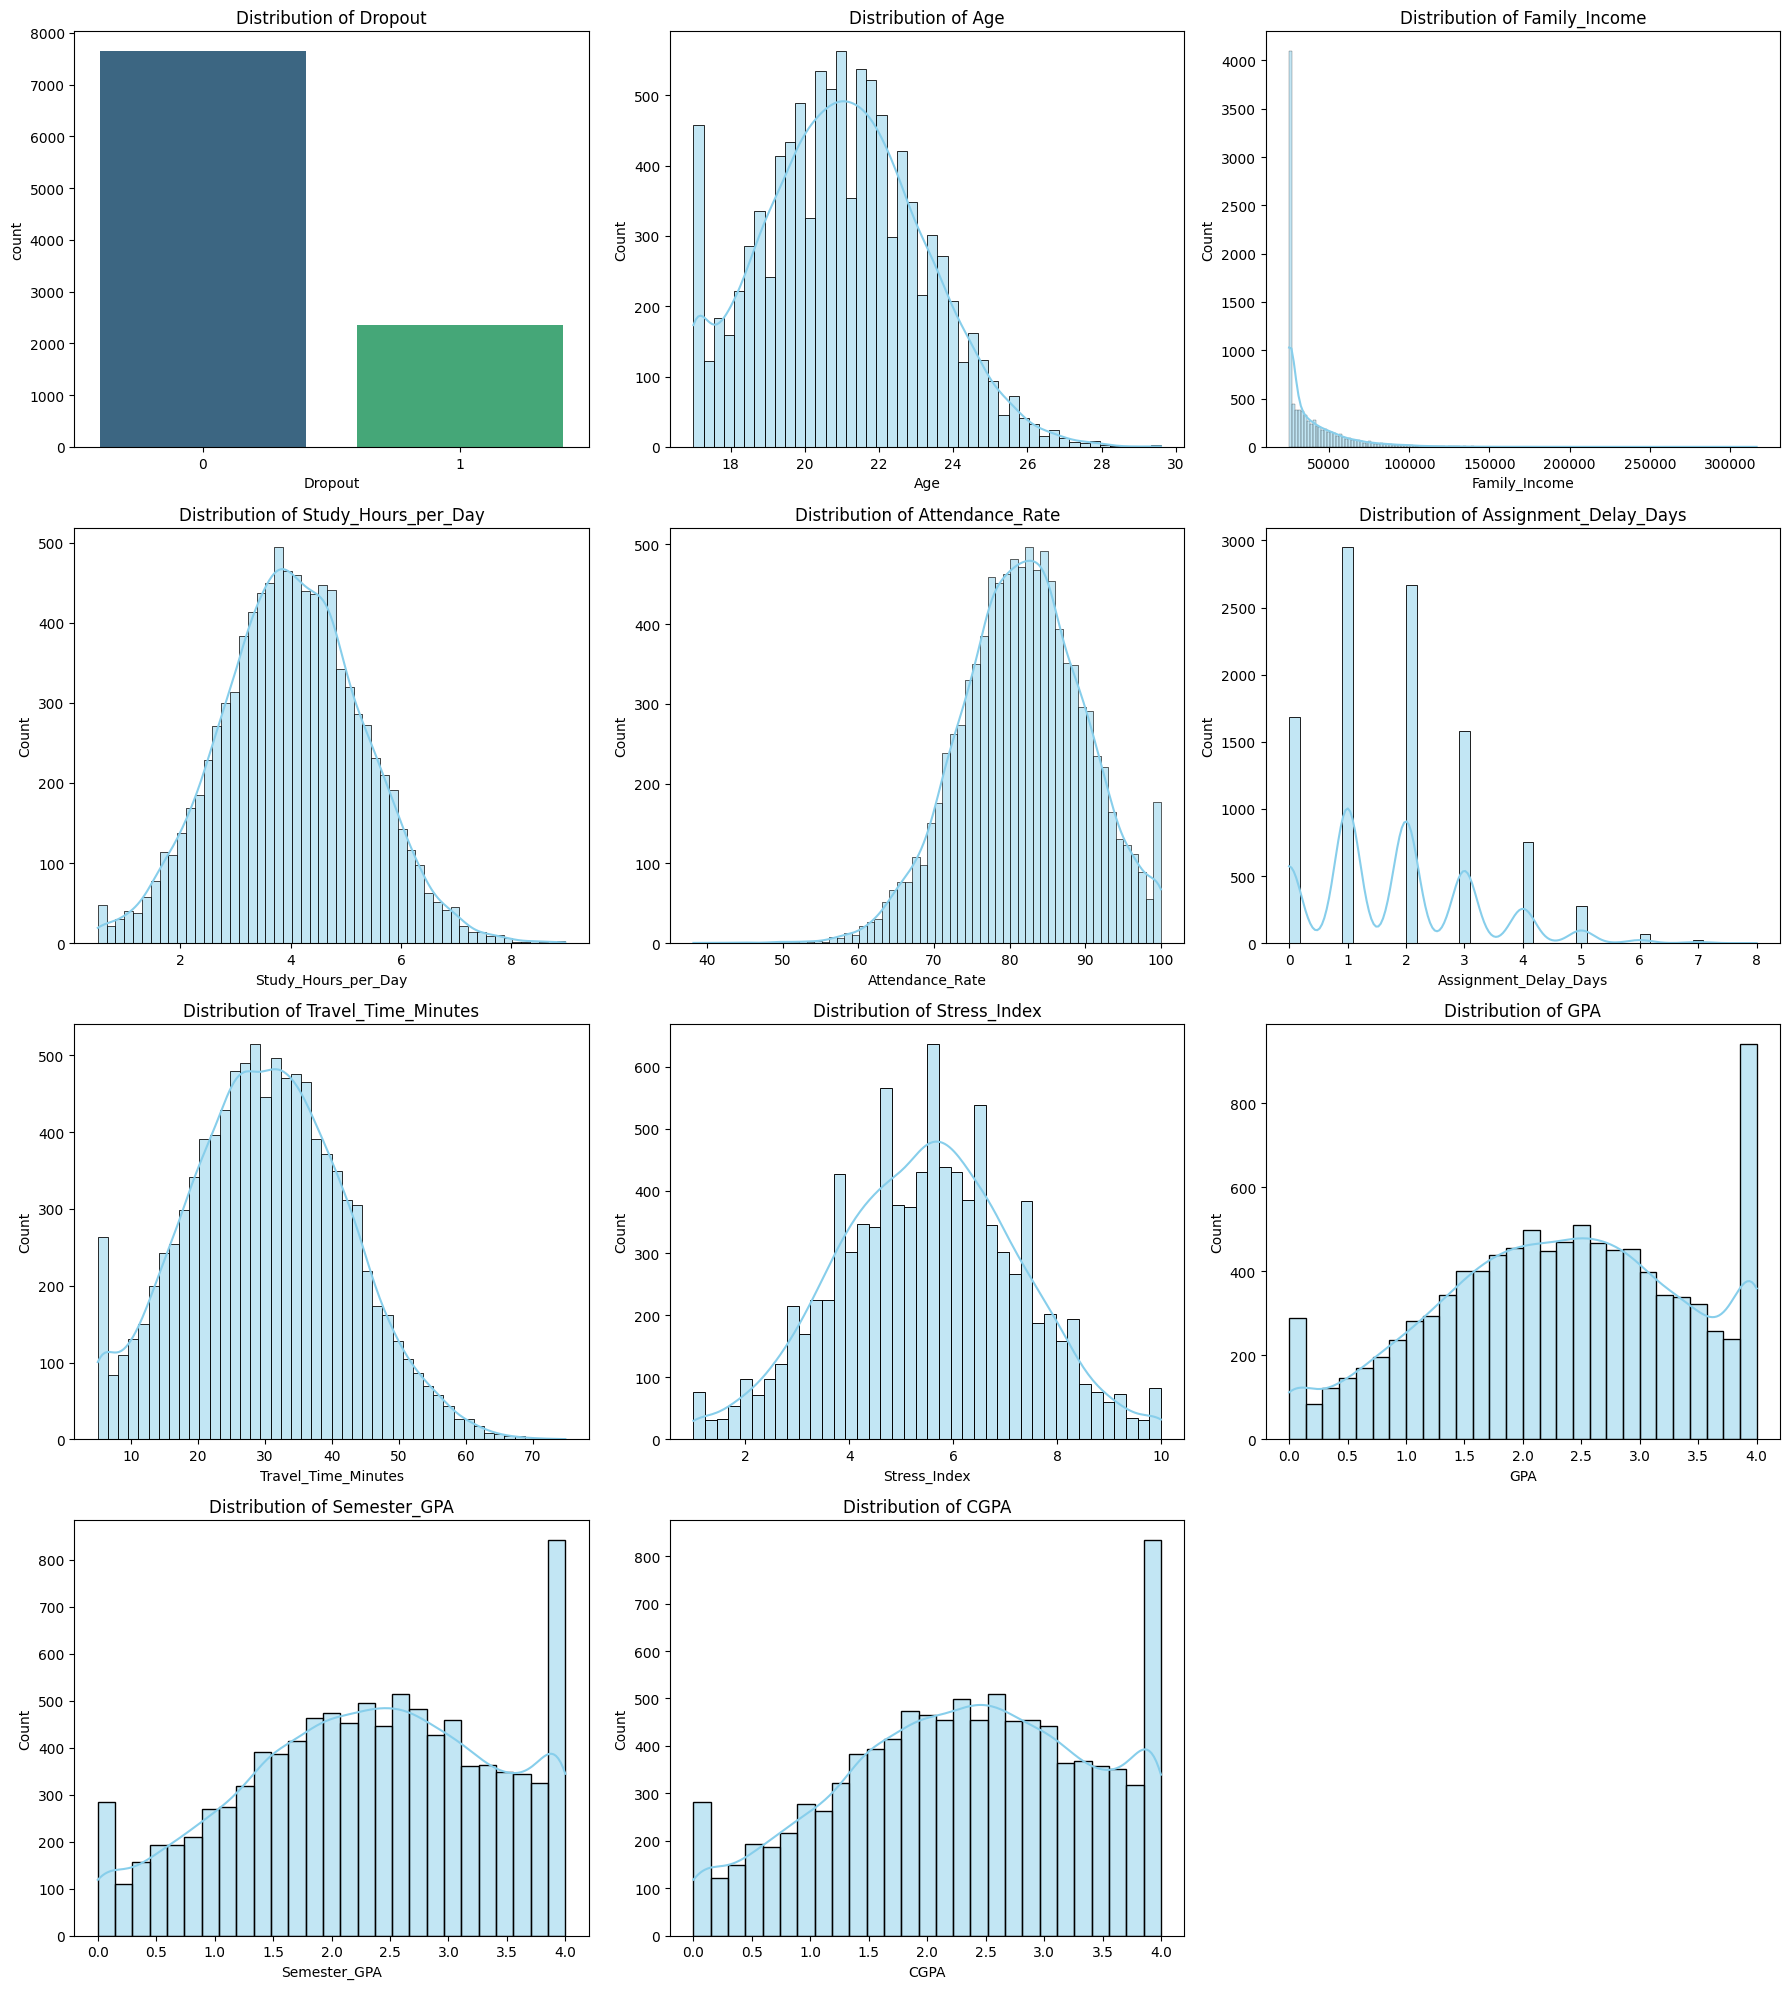

In [ ]:
# Identify target and numerical columns
target_col = 'Dropout' if 'Dropout' in df.columns else df.columns[-1]
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude target and Student_ID from distribution plots
plot_cols = [col for col in num_cols if col not in [target_col, 'Student_ID']]

# Calculate grid size
n_cols = 3
n_rows = (len(plot_cols) + 1 + n_cols - 1) // n_cols

plt.figure(figsize=(18, 5 * n_rows))

# 1. Target Distribution
plt.subplot(n_rows, n_cols, 1)
sns.countplot(x=target_col, data=df, hue=target_col, palette='viridis', legend=False)
plt.title(f'Distribution of {target_col}')

# 2. Numerical Distributions
for i, col in enumerate(plot_cols):
    plt.subplot(n_rows, n_cols, i + 2)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

**Explanation:**

This code performs univariate analysis to understand the distribution of individual variables.

It also automatically detects the 'Dropout' target column and all numerical columns, excluding IDs and the target itself to focus only on features. Additionally, created a count plot to show the balance between 'Dropout' and 'Non-Dropout' classes.

Feature Distributions loops through each numerical feature to create histograms with Kernel Density Estimate (KDE) overlays, to help see the shape, spread, and potential skewness of the data.

### 3. Bivariate Analysis

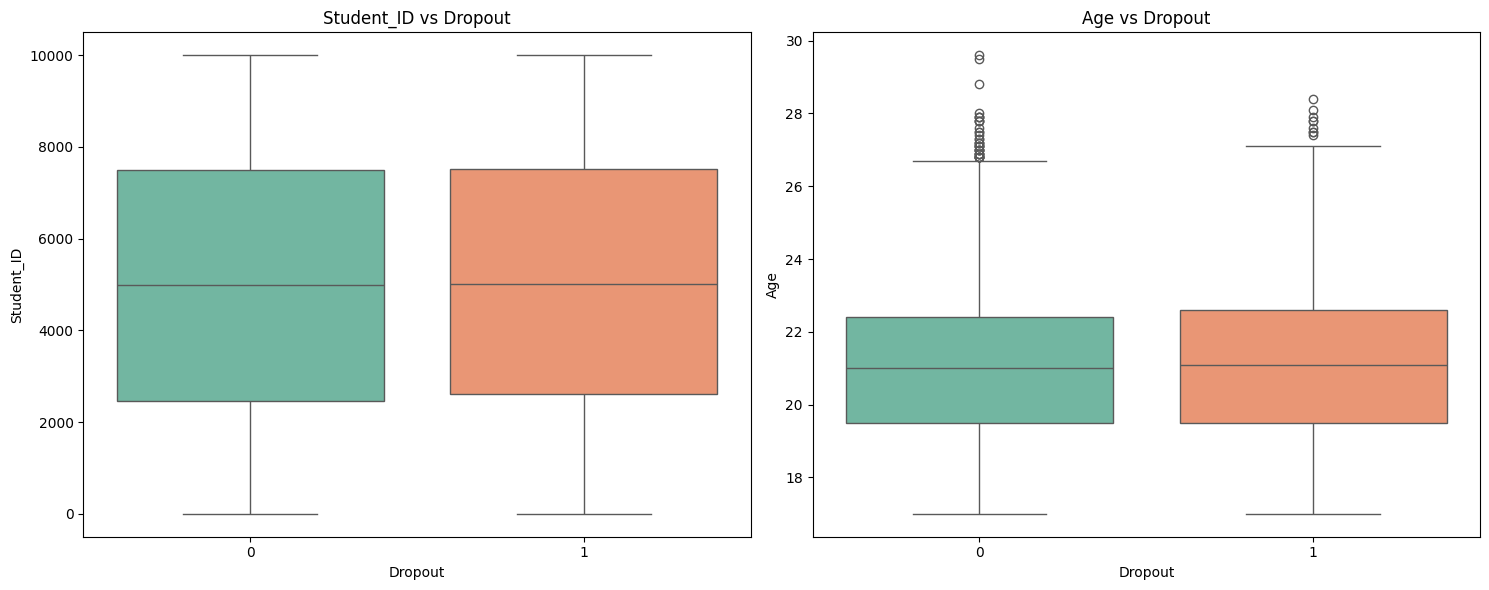

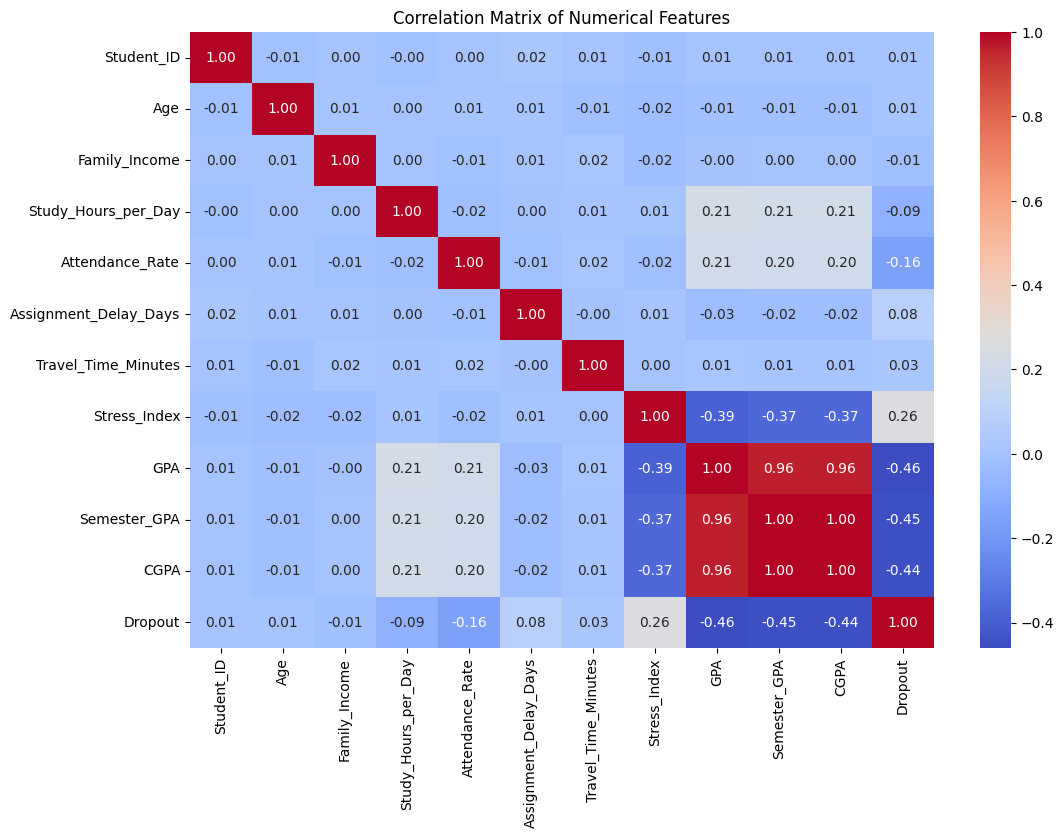

In [ ]:
# Relationship between Numerical Features and Dropout
if len(num_cols) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    sns.boxplot(x=target_col, y=num_cols[0], data=df, ax=axes[0], hue=target_col, palette='Set2', legend=False)
    axes[0].set_title(f'{num_cols[0]} vs {target_col}')

    sns.boxplot(x=target_col, y=num_cols[1], data=df, ax=axes[1], hue=target_col, palette='Set2', legend=False)
    axes[1].set_title(f'{num_cols[1]} vs {target_col}')

    plt.tight_layout()
    plt.show()

# Correlation Heatmap for Multivariate Analysis preview
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Explanation:**

This code performs bivariate analysis to compare features against the Dropout status to find patterns.

Boxplots were created to compare the first two numerical columns in he Dataset (Student_ID and Age) to help identify is they are associated with dropping out.

Heatmap was created to calculate the correlation coefficient between all numerical columns to visualize which variables move together and which are strongly linked to the 'Dropout' target.


> The resulting heatmap uses a 'coolwarm' color scheme (red for positive correlation, blue for negative)



### 4. Data Cleaning and Pre-processing
We will handle the missing values found in the data quality check and address the high correlation between GPA features.

In [ ]:
# 1. Impute Missing Values
df['Family_Income'] = df['Family_Income'].fillna(df['Family_Income'].median())
df['Study_Hours_per_Day'] = df['Study_Hours_per_Day'].fillna(df['Study_Hours_per_Day'].median())
df['Stress_Index'] = df['Stress_Index'].fillna(df['Stress_Index'].median())
df['Parental_Education'] = df['Parental_Education'].fillna(df['Parental_Education'].mode()[0])

# 2. Handle Multicollinearity (GPA columns)
gpa_cols = ['GPA', 'Semester_GPA', 'CGPA']
if all(col in df.columns for col in gpa_cols):
    df['Combined_GPA'] = df[gpa_cols].mean(axis=1)
    df.drop(gpa_cols, axis=1, inplace=True)

# 3. Drop ID if exists
if 'Student_ID' in df.columns:
    df.drop('Student_ID', axis=1, inplace=True)

print("Cleaning and basic feature engineering complete.")

Cleaning and basic feature engineering complete.


**Explanation:**

This code focuses on cleaning the data and performing basic feature engineering

Filled missing values in numerical columns with *median*, and categorical columns with *mode*.

Identified that GPA-related columns are highly correlated. To reduce redundancy, just calculate their average into a new Combined_GPA feature and remove the original columns.

Removed the Student_ID column since unique identifiers don't provide predictive value for machine learning models.

### 5. Multivariate Analysis


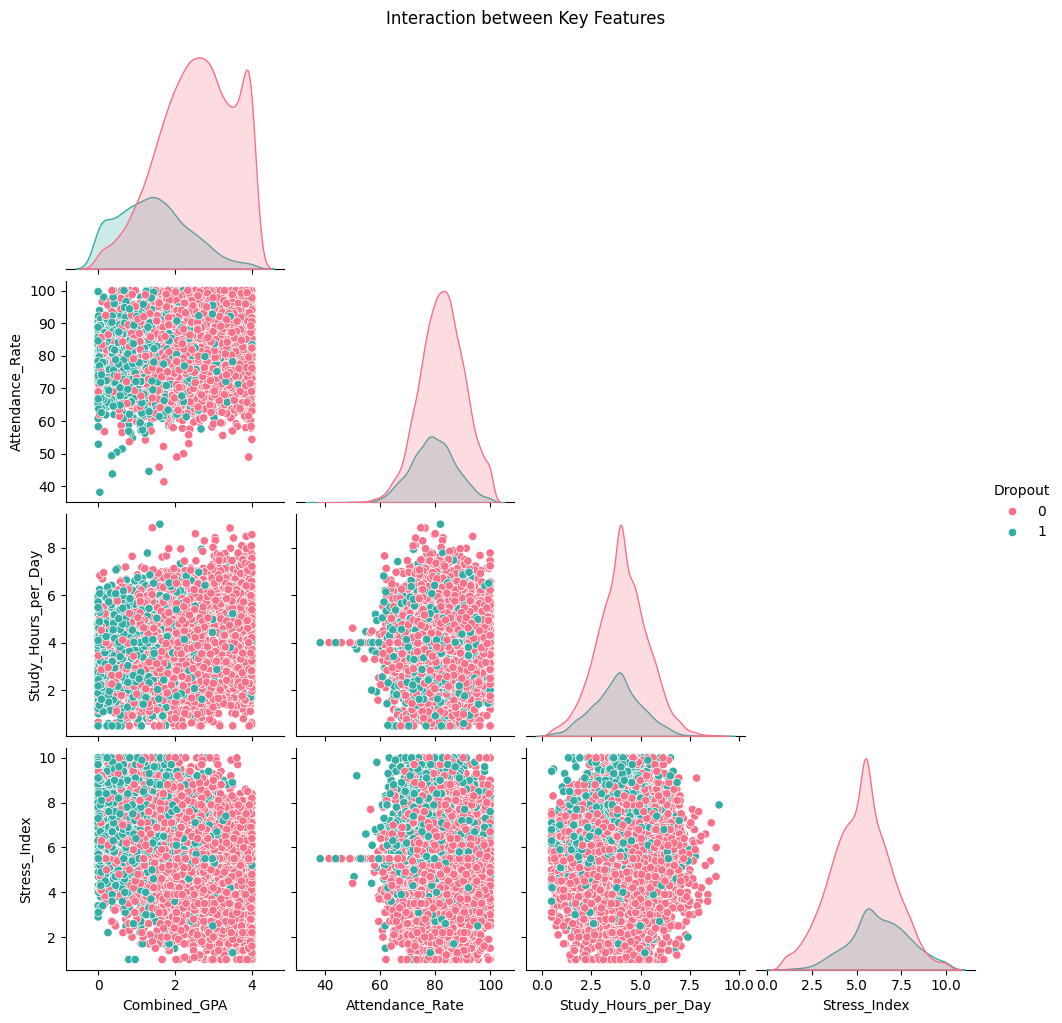

In [ ]:
# Selecting a subset of important features for the pairplot to keep it readable
important_features = ['Combined_GPA', 'Attendance_Rate', 'Study_Hours_per_Day', 'Stress_Index', 'Dropout']
sns.pairplot(df[important_features], hue='Dropout', palette='husl', corner=True)
plt.suptitle('Interaction between Key Features', y=1.02)
plt.show()

**Explanation:**

This code performs multivariate analysis using a pairplot to visualize how multiple features interact simultaneously.

Defines a subset of important features for readable visual.

Using sns.pairplot, to create a grid of scatter plots for each pair of features.

The hue='Dropout' parameter colors the data points based on whether a student dropped out



### 6. Categorical Encoding and Feature Scaling


In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. One-Hot Encoding for Categorical Columns
# We exclude 'Dropout' as it is our binary target
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [col for col in cat_cols if col != 'Dropout']
df_final = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# 2. Feature Scaling
scaler = StandardScaler()
# Scale all numerical features except the target 'Dropout'
features_to_scale = df_final.select_dtypes(include=[np.number]).columns.tolist()
if 'Dropout' in features_to_scale: features_to_scale.remove('Dropout')

df_final[features_to_scale] = scaler.fit_transform(df_final[features_to_scale])

print("Final Preprocessing Complete!")
print(f"Final features shape: {df_final.shape}")
display(df_final.head())

Final Preprocessing Complete!
Final features shape: (10000, 23)


,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,Dropout,Combined_GPA,Gender_Male,...,Semester_Year 2,Semester_Year 3,Semester_Year 4,Department_Business,Department_CS,Department_Engineering,Department_Science,Parental_Education_High School,Parental_Education_Master,Parental_Education_PhD
0,0.501911,-0.645184,-0.517875,0.530766,0.149006,-0.820527,-0.003945,0,-1.303164,True,...,False,False,False,False,False,False,False,True,False,False
1,-0.152386,-0.645184,0.226629,-1.671042,0.149006,1.159626,0.751366,1,-1.017221,True,...,False,True,False,False,False,True,False,False,False,False
2,0.642117,0.111519,0.305831,-1.318266,-1.338824,1.570759,-0.003945,0,-0.812976,True,...,False,False,False,False,False,False,False,False,True,False
3,1.576826,-0.408923,-0.010979,0.056343,0.149006,0.706540,-0.003945,1,-0.498753,True,...,False,False,False,False,True,False,False,True,False,False
4,-0.245857,-0.629285,0.139506,-0.734361,-0.594909,-0.602374,0.867567,0,-1.146053,False,...,False,False,True,True,False,False,False,False,False,False


**Explanation:**

This code performs One-Hot Encoding anf StandardScaler.

> One-Hot Encoding: identifies all categorical (object) columns, excluding the target 'Dropout', and converts them into numerical variables.


> StadardScaler: it transforms numerical features so they have a mean of 0 and a standard deviation of 1.


### Summary of EDA Observations

1. **Class Imbalance**: The target variable `Dropout` is imbalanced, with approximately 23.5% of students having dropped out, suggesting we need to be careful with evaluation metrics during modeling.
2. **Missing Data Patterns**: Significant missing values were found in sensitive areas like `Family_Income` and `Parental_Education`, which required median and mode imputation respectively.
3. **Multicollinearity in Academic Performance**: The features `GPA`, `Semester_GPA`, and `CGPA` show a near-perfect correlation (above 0.9), indicating they provide redundant information and were successfully combined into a single feature.
4. **Correlation with Dropout**: Initial bivariate analysis indicates that lower GPA and lower attendance rates are strongly associated with higher dropout instances.
5. **Demographic Distribution**: The student population is spread across five departments, with 'Arts' serving as a baseline group in our encoding, and age distribution appearing relatively narrow within the typical university range.

### 7. Model Training and Evaluation

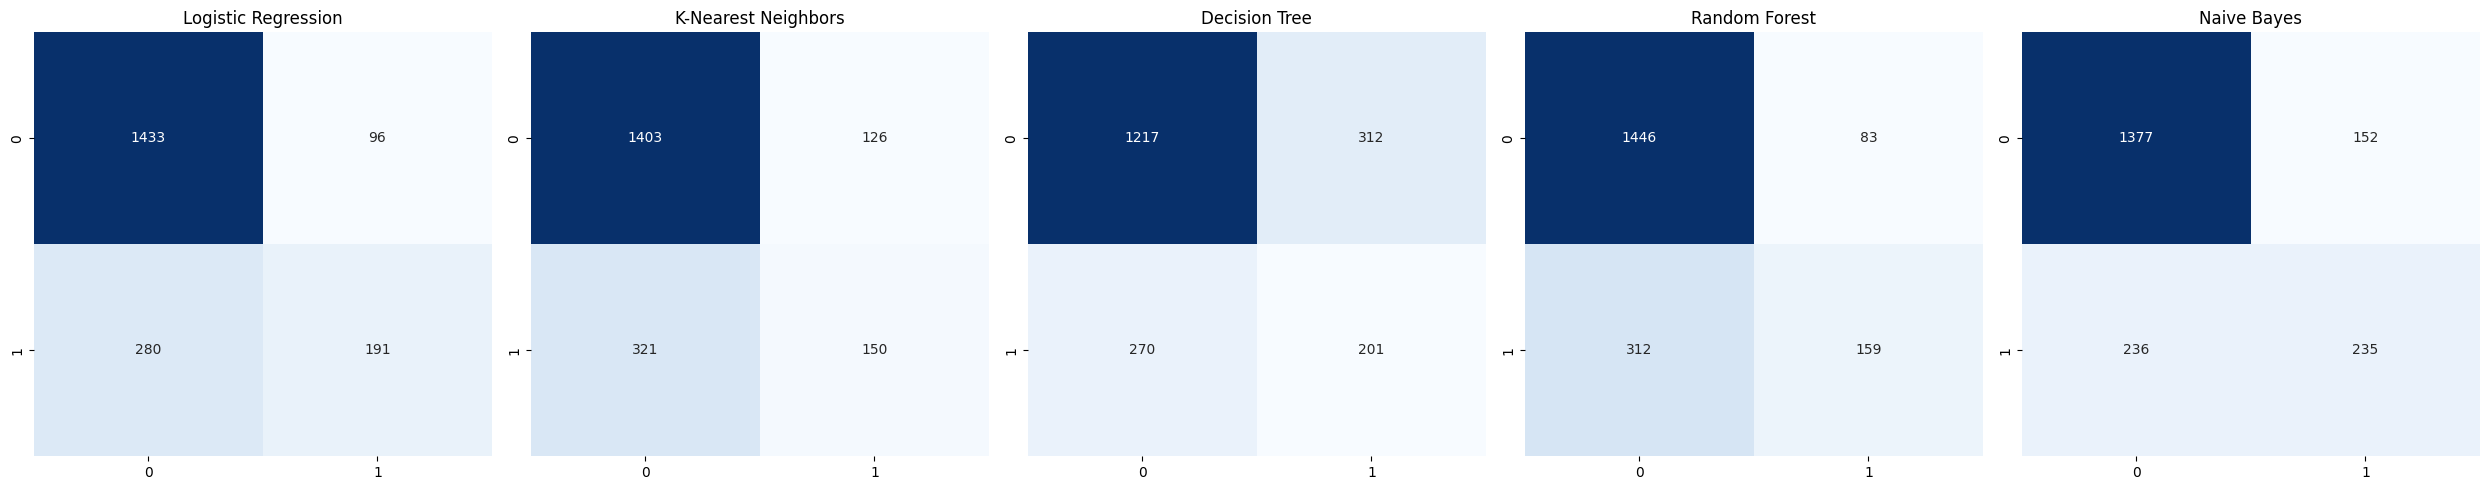

,Model,Accuracy,Precision,Recall,F1 Score
4,Naive Bayes,0.8060,0.607235,0.498938,0.547786
0,Logistic Regression,0.8120,0.665505,0.405520,0.503958
3,Random Forest,0.8025,0.657025,0.337580,0.446003
2,Decision Tree,0.7090,0.391813,0.426752,0.408537
1,K-Nearest Neighbors,0.7765,0.543478,0.318471,0.401606


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Impute and Clean (matching step 4 and 6)
df['Family_Income'] = df['Family_Income'].fillna(df['Family_Income'].median())
df['Study_Hours_per_Day'] = df['Study_Hours_per_Day'].fillna(df['Study_Hours_per_Day'].median())
df['Stress_Index'] = df['Stress_Index'].fillna(df['Stress_Index'].median())
df['Parental_Education'] = df['Parental_Education'].fillna(df['Parental_Education'].mode()[0])

gpa_cols = ['GPA', 'Semester_GPA', 'CGPA']
if all(col in df.columns for col in gpa_cols):
    df['Combined_GPA'] = df[gpa_cols].mean(axis=1)
    df.drop(gpa_cols, axis=1, inplace=True)

if 'Student_ID' in df.columns:
    df.drop('Student_ID', axis=1, inplace=True)

# Encoding and Scaling
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols = [col for col in cat_cols if col != 'Dropout']
df_final = pd.get_dummies(df, columns=cat_cols, drop_first=True)

scaler = StandardScaler()
features_to_scale = df_final.select_dtypes(include=[np.number]).columns.tolist()
if 'Dropout' in features_to_scale: features_to_scale.remove('Dropout')
df_final[features_to_scale] = scaler.fit_transform(df_final[features_to_scale])

# Prepare Features and Target
X = df_final.drop('Dropout', axis=1)
y = df_final['Dropout']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Naive Bayes': GaussianNB()
}

# Train and Evaluate
results = []
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues', cbar=False)
    axes[i].set_title(name)

plt.tight_layout()
plt.show()

display(pd.DataFrame(results).sort_values(by='F1 Score', ascending=False))

### 8. Model Comparison Summary

In [ ]:
import pandas as pd

# Create the comparison dataframe from the results collected during training
comparison_df = pd.DataFrame(results)

# Sort by F1 Score descending for better readability
comparison_df = comparison_df.sort_values(by='F1 Score', ascending=False).reset_index(drop=True)

print("Model Comparison Table:")
display(comparison_df.style.background_gradient(cmap='Blues'))

Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.806000,0.607235,0.498938,0.547786
1,Logistic Regression,0.812000,0.665505,0.405520,0.503958
2,Random Forest,0.802500,0.657025,0.337580,0.446003
3,Decision Tree,0.709000,0.391813,0.426752,0.408537
4,K-Nearest Neighbors,0.776500,0.543478,0.318471,0.401606
